# Urban Heat Island (UHI) Effect Analysis — Lagos State, Nigeria

This project analyzes the **Urban Heat Island (UHI) effect** in Lagos State using real daily temperature data for 2024, comparing an urban point (Ikeja / Lagos mainland) against a rural point (Epe, a predominantly agrarian LGA in eastern Lagos State).

**Data sources** (see [`scripts/fetch_data.py`](../scripts/fetch_data.py) for the full pipeline, all public, no API key required):
- **ERA5-Land reanalysis** (ECMWF, via the [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api)) for daily max/min/mean temperature at the urban and rural points. Reanalysis blends real observations, satellite data, and a physical land-surface model onto a ~9 km grid — it's used here because **no public rural ground station exists near Lagos**.
- **Real station observations** from [NOAA GHCN-Daily](https://www.ncei.noaa.gov/pub/data/ghcn/daily/), station `NIM00065201` (Murtala Muhammed International Airport, Lagos), used to validate the ERA5-Land urban series against actual ground-truth measurements.

**Objectives**
- Validate the reanalysis data against a real weather station before trusting it for the urban-rural comparison.
- Quantify the UHI effect (urban − rural), including how it differs between daytime highs and nighttime lows.
- Identify seasonal patterns in the UHI effect through 2024.

**Honesty about limitations**: this is a two-point comparison built on ~9 km reanalysis grid cells, not high-resolution satellite land-surface temperature (e.g. MODIS/Landsat) or a dense station network — see [Limitations](#8.-Limitations-and-next-steps) at the end for what a more rigorous version of this analysis would require.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = pd.read_csv("../data/lagos_uhi_2024.csv", parse_dates=["Date"])
station = pd.read_csv("../data/lagos_airport_station_2024.csv", parse_dates=["Date"])

data.head()

,Date,Urban_Temperature,Rural_Temperature,Temperature_Difference,Urban_TMax,Urban_TMin,Rural_TMax,Rural_TMin
0,2024-01-01,27.7,27.8,-0.1,34.2,23.3,33.3,23.9
1,2024-01-02,27.9,28.0,-0.1,34.9,23.0,34.2,23.8
2,2024-01-03,27.6,27.7,-0.1,32.7,23.8,31.6,23.9
3,2024-01-04,27.8,27.8,0.0,33.6,24.0,32.3,24.7
4,2024-01-05,27.5,27.6,-0.1,32.3,24.2,32.2,24.5


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    366 non-null    datetime64[us]
 1   Urban_Temperature       366 non-null    float64       
 2   Rural_Temperature       366 non-null    float64       
 3   Temperature_Difference  366 non-null    float64       
 4   Urban_TMax              366 non-null    float64       
 5   Urban_TMin              366 non-null    float64       
 6   Rural_TMax              366 non-null    float64       
 7   Rural_TMin              366 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 23.0 KB


## 2. Validate the reanalysis data against a real weather station

Before trusting ERA5-Land as a stand-in for ground truth, it's checked against real observations from Murtala Muhammed International Airport — the only public weather station near Lagos, located almost exactly at the "urban" point used here.

In [3]:
compare = data[["Date", "Urban_TMax", "Urban_TMin"]].merge(
    station[["Date", "TMAX", "TMIN"]], on="Date", how="inner"
)
compare["TMax_Error"] = compare["Urban_TMax"] - compare["TMAX"]
compare["TMin_Error"] = compare["Urban_TMin"] - compare["TMIN"]

print(f"Matched days: {len(compare)}")
print(f"TMax - mean absolute error: {compare['TMax_Error'].abs().mean():.2f} degC, "
      f"correlation: {compare['Urban_TMax'].corr(compare['TMAX']):.2f}")
print(f"TMin - mean absolute error: {compare['TMin_Error'].abs().mean():.2f} degC, "
      f"correlation: {compare['Urban_TMin'].corr(compare['TMIN']):.2f}")

Matched days: 355
TMax - mean absolute error: 1.36 degC, correlation: 0.90
TMin - mean absolute error: 1.02 degC, correlation: 0.63


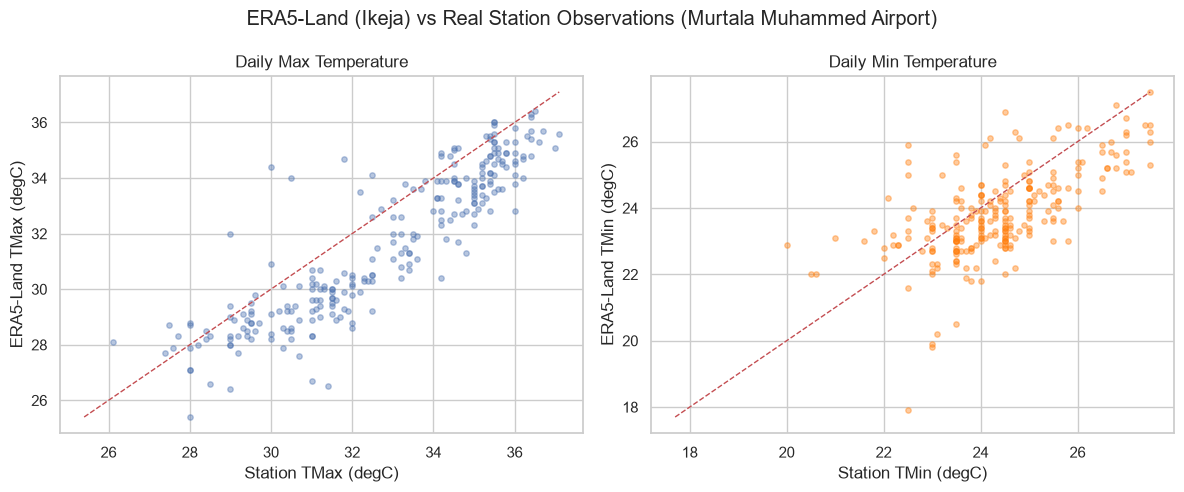

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(compare["TMAX"], compare["Urban_TMax"], alpha=0.4, s=15)
lims = [compare[["TMAX", "Urban_TMax"]].min().min(), compare[["TMAX", "Urban_TMax"]].max().max()]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Station TMax (degC)")
axes[0].set_ylabel("ERA5-Land TMax (degC)")
axes[0].set_title("Daily Max Temperature")

axes[1].scatter(compare["TMIN"], compare["Urban_TMin"], alpha=0.4, s=15, color="tab:orange")
lims = [compare[["TMIN", "Urban_TMin"]].min().min(), compare[["TMIN", "Urban_TMin"]].max().max()]
axes[1].plot(lims, lims, "r--", linewidth=1)
axes[1].set_xlabel("Station TMin (degC)")
axes[1].set_ylabel("ERA5-Land TMin (degC)")
axes[1].set_title("Daily Min Temperature")

fig.suptitle("ERA5-Land (Ikeja) vs Real Station Observations (Murtala Muhammed Airport)")
plt.tight_layout()
plt.savefig("../images/station_validation.png", dpi=150)
plt.show()

Daytime highs (TMax) agree closely with the real station (r ≈ 0.90, ~1.4°C average error) — reanalysis captures the daily heating cycle well. Nighttime lows (TMin) agree less closely (r ≈ 0.63) — reanalysis has more trouble resolving local nighttime cooling processes at ~9 km resolution. This matters for the rest of the analysis: the daytime comparison is on firmer ground than the nighttime one.

## 3. Urban vs. rural temperature trends

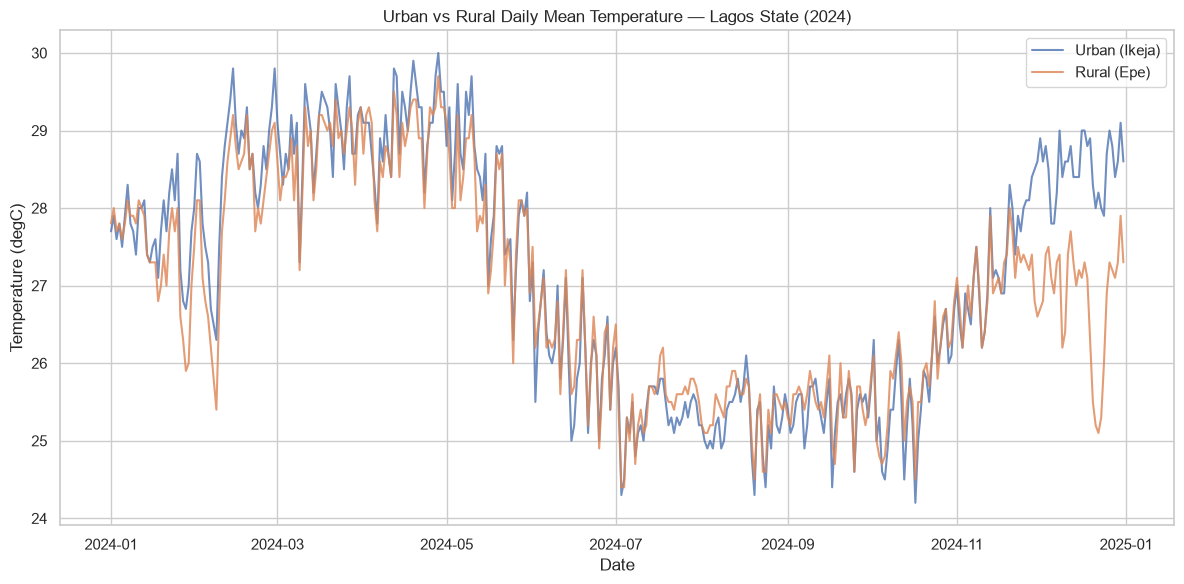

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(data["Date"], data["Urban_Temperature"], label="Urban (Ikeja)", alpha=0.8)
plt.plot(data["Date"], data["Rural_Temperature"], label="Rural (Epe)", alpha=0.8)
plt.title("Urban vs Rural Daily Mean Temperature — Lagos State (2024)")
plt.xlabel("Date")
plt.ylabel("Temperature (degC)")
plt.legend()
plt.tight_layout()
plt.savefig("../images/urban_vs_rural_trend.png", dpi=150)
plt.show()

## 4. The UHI effect is mostly a daytime signal here

A single "mean temperature difference" can hide what's actually happening, since the urban-rural gap can behave very differently at midday than at night. Splitting the difference into daytime highs (TMax) and nighttime lows (TMin) gives a clearer, more honest picture.

In [6]:
data["TMax_Diff"] = data["Urban_TMax"] - data["Rural_TMax"]
data["TMin_Diff"] = data["Urban_TMin"] - data["Rural_TMin"]

summary = pd.DataFrame({
    "Mean Temperature": [data["Urban_Temperature"].mean(), data["Rural_Temperature"].mean(), data["Temperature_Difference"].mean()],
    "Daytime High (TMax)": [data["Urban_TMax"].mean(), data["Rural_TMax"].mean(), data["TMax_Diff"].mean()],
    "Nighttime Low (TMin)": [data["Urban_TMin"].mean(), data["Rural_TMin"].mean(), data["TMin_Diff"].mean()],
}, index=["Urban avg (degC)", "Rural avg (degC)", "Urban minus rural (degC)"])

summary.round(2)

,Mean Temperature,Daytime High (TMax),Nighttime Low (TMin)
Urban avg (degC),27.17,31.78,24.02
Rural avg (degC),26.94,30.87,24.24
Urban minus rural (degC),0.22,0.91,-0.21


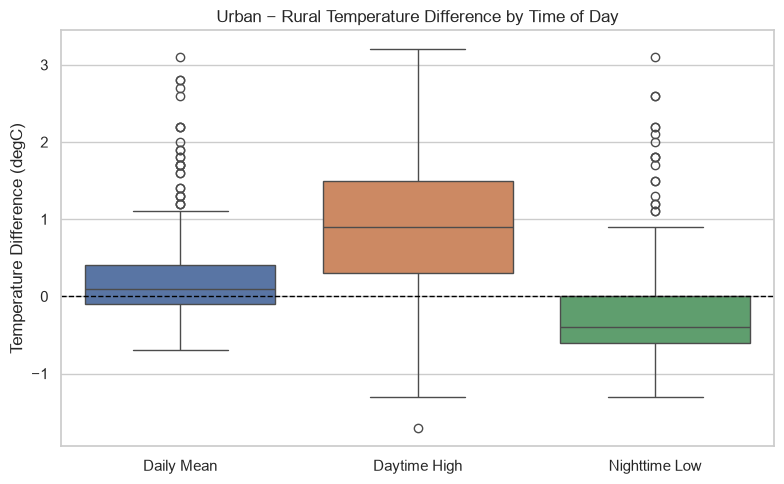

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data[["Temperature_Difference", "TMax_Diff", "TMin_Diff"]])
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.xticks([0, 1, 2], ["Daily Mean", "Daytime High", "Nighttime Low"])
plt.title("Urban − Rural Temperature Difference by Time of Day")
plt.ylabel("Temperature Difference (degC)")
plt.tight_layout()
plt.savefig("../images/diurnal_uhi_effect.png", dpi=150)
plt.show()

The daytime high in Ikeja runs about +0.9°C above Epe on average (up to +3.2°C on the hottest days) — a real, if modest, daytime UHI signal. Nighttime lows, on the other hand, run slightly *cooler* in Ikeja than in Epe on average (-0.2°C) — the opposite of the classic "city traps heat overnight" textbook pattern. A plausible explanation is that both points sit close to the Lagos coastline/lagoon system, and nighttime sea/lagoon breezes may moderate urban cooling more than the land-use difference alone would predict; it could also partly reflect the weaker nighttime accuracy of the reanalysis noted in the validation step above. Either way, this is a more nuanced and more credible finding than assuming a uniform day-and-night UHI effect.

## 5. Seasonal pattern in the daytime UHI effect

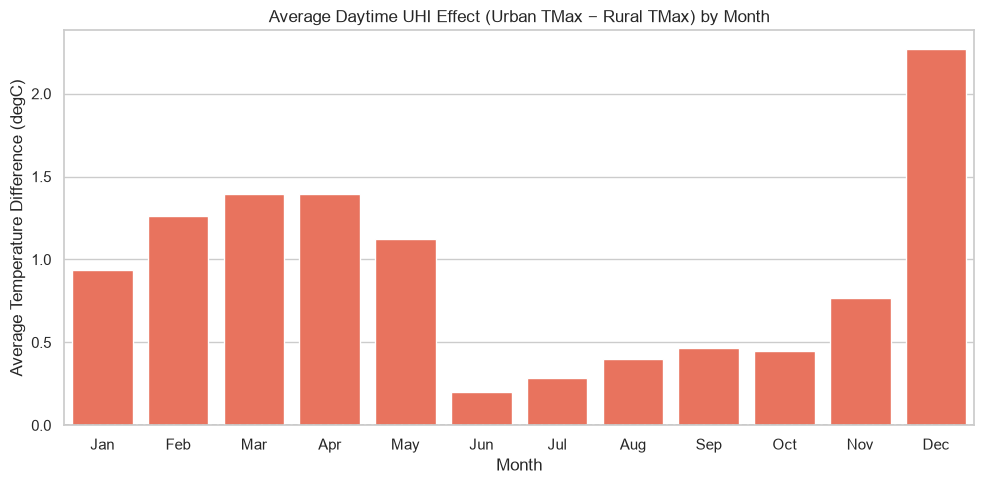

,TMax_Diff,TMin_Diff,Temperature_Difference
Date,,,
Jan,0.94,-0.12,0.27
Feb,1.26,0.07,0.46
Mar,1.39,-0.44,0.18
Apr,1.39,-0.45,0.19
May,1.13,-0.33,0.24
Jun,0.20,-0.39,-0.12
Jul,0.29,-0.44,-0.14
Aug,0.40,-0.54,-0.15
Sep,0.47,-0.48,-0.08


In [8]:
data["Month"] = data["Date"].dt.month_name()
monthly = (
    data.groupby(data["Date"].dt.month)[["TMax_Diff", "TMin_Diff", "Temperature_Difference"]]
    .mean()
)
monthly.index = pd.to_datetime(monthly.index, format="%m").strftime("%b")

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly["TMax_Diff"], color="tomato")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.title("Average Daytime UHI Effect (Urban TMax − Rural TMax) by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature Difference (degC)")
plt.tight_layout()
plt.savefig("../images/monthly_uhi_effect.png", dpi=150)
plt.show()

monthly.round(2)

The daytime UHI effect is present every month, but it is not constant: it is roughly **2-3x stronger in the dry season (November-May, +0.9 to +1.4 degC, peaking above +2 degC in December)** than in the rainy season (June-October, +0.2 to +0.5 degC). This lines up with Lagos's climate: the rainy season brings frequent cloud cover and rainfall that limit solar heating and add evaporative cooling almost everywhere, narrowing the urban-rural gap, while the sunnier, drier months let the urban surface's extra heat absorption show through more clearly. December's spike coincides with the Harmattan season, when dry, dusty conditions and reduced cloud cover in the region tend to widen daytime temperature extremes.

## 6. Summary statistics

In [9]:
insights = {
    "Mean Urban Temperature (degC)": data["Urban_Temperature"].mean(),
    "Mean Rural Temperature (degC)": data["Rural_Temperature"].mean(),
    "Average Daily-Mean UHI Effect (degC)": data["Temperature_Difference"].mean(),
    "Average Daytime UHI Effect (degC)": data["TMax_Diff"].mean(),
    "Average Nighttime UHI Effect (degC)": data["TMin_Diff"].mean(),
    "Maximum Daytime UHI Effect (degC)": data["TMax_Diff"].max(),
    "Days Urban Daytime High Exceeds Rural": int((data["TMax_Diff"] > 0).sum()),
    "Total Days": len(data),
}

for key, value in insights.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

Mean Urban Temperature (degC): 27.17
Mean Rural Temperature (degC): 26.94
Average Daily-Mean UHI Effect (degC): 0.22
Average Daytime UHI Effect (degC): 0.91
Average Nighttime UHI Effect (degC): -0.21
Maximum Daytime UHI Effect (degC): 3.20
Days Urban Daytime High Exceeds Rural: 311
Total Days: 366


## 7. Conclusion

Comparing an urban point in Ikeja against a rural point in Epe using real 2024 temperature data (ERA5-Land reanalysis, validated against a real airport weather station) shows a genuine but modest **daytime** Urban Heat Island effect of roughly **+0.9°C on average**, reaching **+3.2°C** on the most extreme days, present across every month of the year but **2-3x stronger in the dry season than in the rainy season**. Unlike the classic textbook UHI pattern, this effect does not clearly extend into the nighttime hours at this resolution — nighttime lows in Ikeja run marginally cooler than in Epe on average.

This is a smaller and more nuanced effect than a simulated dataset would show, which is exactly the point: real data doesn't always confirm the textbook story, and a two-point, ~9 km-resolution reanalysis comparison can only detect part of what's really happening on the ground.

## 8. Limitations and next steps

- **Spatial resolution**: ERA5-Land's ~9 km grid cells blend urban and surrounding land cover, which dilutes the true urban heat signal compared to what a resident would experience standing on hot asphalt in central Lagos. A satellite-based land surface temperature product (e.g. MODIS MOD11A2 or Landsat 8/9 thermal bands, both accessible via Google Earth Engine) would resolve intra-city variation far better.
- **Two-point comparison**: this compares one urban and one rural point, not a full urban-vs-rural land-cover classification across Lagos State. A raster-based approach (comparing average LST across built-up vs. vegetated/agricultural pixels) would be more robust.
- **Single rural proxy**: Epe was chosen because it is a real place with a predominantly agrarian character, but its own proximity to the Lagos Lagoon may moderate its temperatures in ways that don't generalize to all rural areas of the state.
- **Nighttime validation gap**: the weaker station agreement for TMin (r ≈ 0.63) means the nighttime finding above should be treated as a hypothesis, not a settled result — it would benefit from a second real nighttime-observing station or higher-resolution nighttime LST data.
- **One year of data**: 2024 alone can't separate a genuine climatological pattern from one year's weather variability; multi-year data would let the seasonal analysis distinguish trend from noise.